In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

In [9]:
df = pd.read_csv("fcc-forum-pageviews.csv", index_col="date", parse_dates=["date"])
df

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933
...,...
2019-11-29,171584
2019-11-30,141161
2019-12-01,142918


In [10]:
lower = df["value"].quantile(0.025)
upper = df["value"].quantile(0.975)
df = df[(df["value"] >= lower) & (df["value"] <= upper)]
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


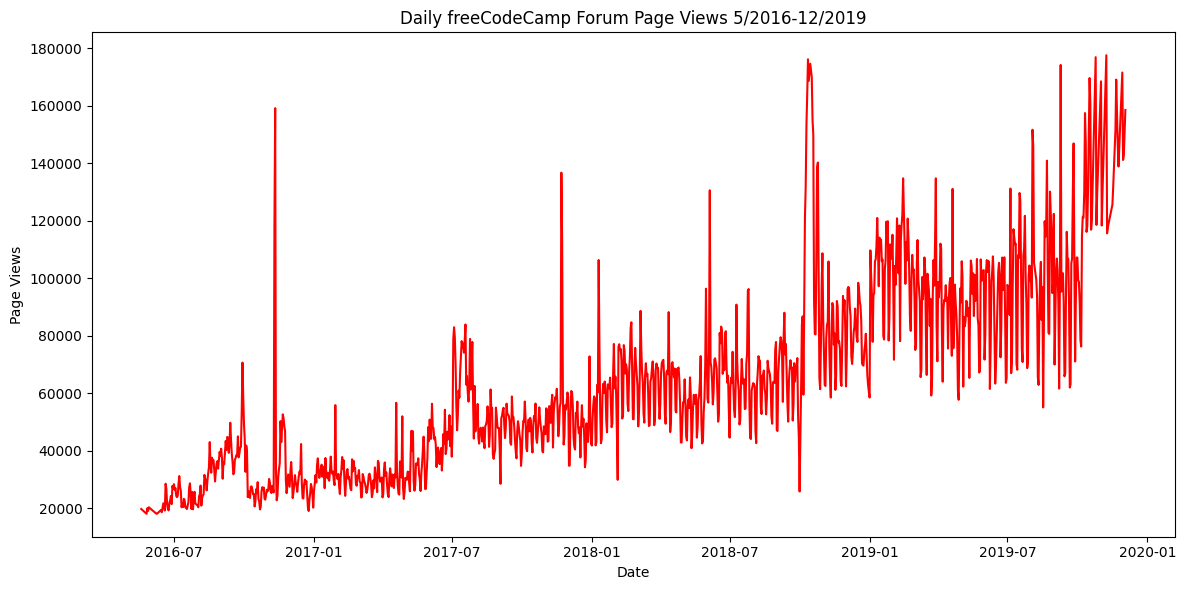

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df["value"], color="red")
ax.set_title("Daily freeCodeCamp Forum Page Views 5/2016-12/2019")
ax.set_xlabel("Date")
ax.set_ylabel("Page Views")
plt.tight_layout()

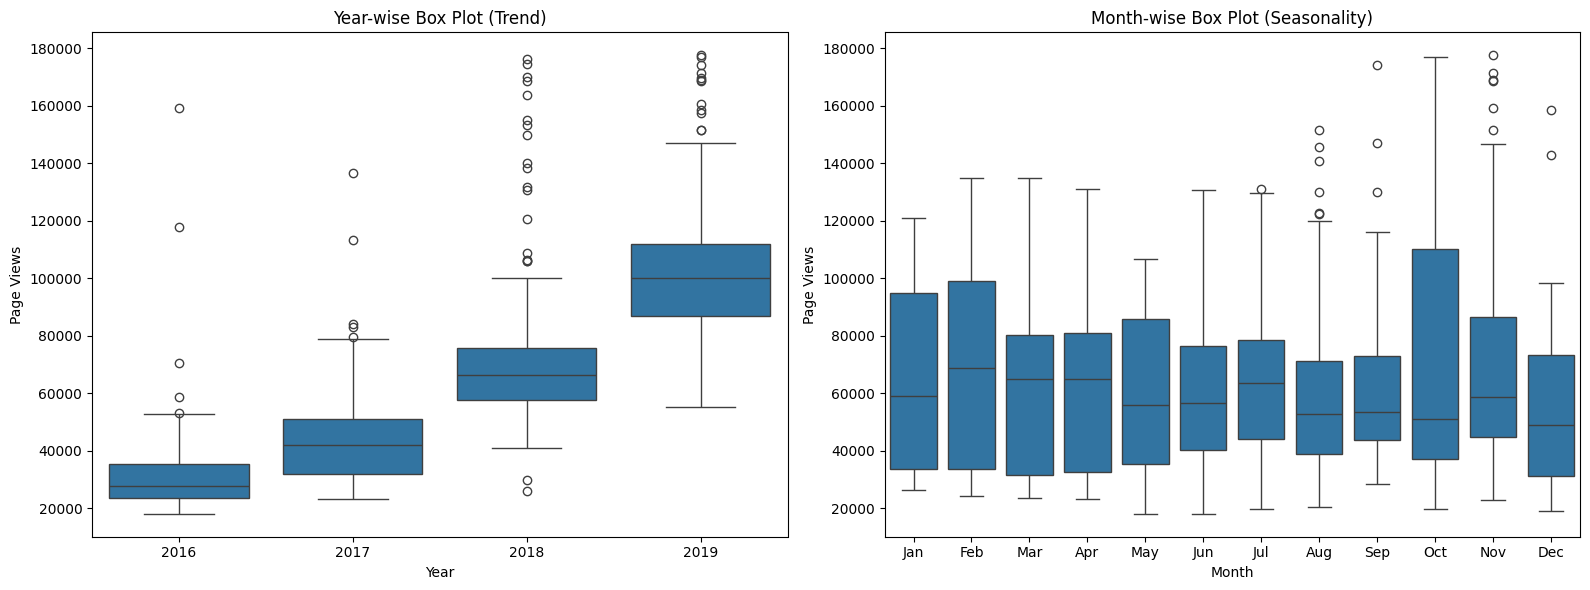

In [14]:
df_box = df.copy()
df_box["year"] = df_box.index.year
df_box["month"] = df_box.index.strftime("%b")
df_box["month_num"] = df_box.index.month
df_box = df_box.sort_values("month_num")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="year", y="value", data=df_box, ax=axes[0])
axes[0].set_title("Year-wise Box Plot (Trend)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Page Views")

sns.boxplot(x="month", y="value", data=df_box, ax=axes[1])
axes[1].set_title("Month-wise Box Plot (Seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Page Views")

plt.tight_layout()